In [3]:
import scanpy as sc
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
import phate
import sys
from tqdm import tqdm
sys.path.insert(0, os.path.abspath("../torch-cfm"))
import importlib

# Import the modules themselves
import torchcfm.conditional_flow_matching as cfm
import torchcfm.models as models
import torchcfm.utils as utils
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

# Testing PCA embedding based torchcfm on drosophila dataset 
*For phate-embedding basis, as in example torchcfm notebook, see test_ot_cfm.ipynb*

In [4]:
#Read file 
dr_data_path = "/home/mcb/users/msandl4/scTimeBench/data/DR/drosophila.h5ad"
adata = sc.read_h5ad(dr_data_path)

In [5]:
sc.tl.pca(adata, n_comps=50)

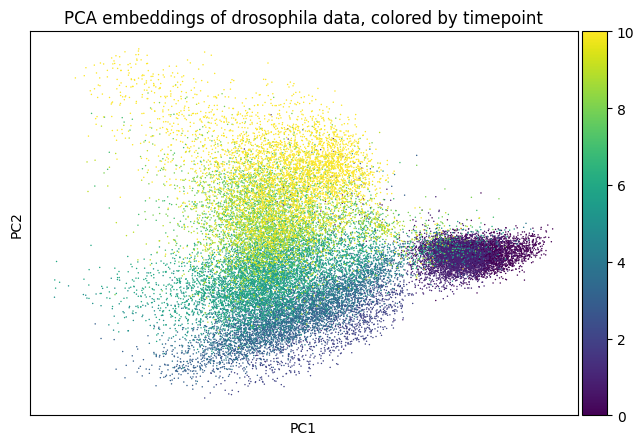

In [8]:
sc.pl.scatter(adata, basis="pca", color="timepoint", title="PCA embeddings of drosophila data, colored by timepoint")

In [9]:
timepoints = sorted(adata.obs["timepoint"].unique())

In [10]:
n_times = len(timepoints)

X = [
    adata.obsm["X_pca"][adata.obs["timepoint"] == t]
    for t in timepoints
]

In [11]:
def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

In [12]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256

In [13]:
def train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000):
    for i in tqdm(range(10000)):
        ot_cfm_optimizer.zero_grad()
        t, xt, ut = get_batch(FM, X, batch_size, n_times)
        vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        ot_cfm_optimizer.step()

In [22]:
import scprep
def plot_trajectories(traj, legend=True):
    n = 1000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata.obsm["X_pca"][:, 0],
        adata.obsm["X_pca"][:, 1],
        title = "CFM trajectories",
        c=adata.obs["timepoint"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")

In [18]:
def plot_node_path(ot_cfm_model, X):
    node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
    with torch.no_grad():
        traj = node.trajectory(
            torch.from_numpy(X[0][:1000]).float().to(device),
            t_span=torch.linspace(0, n_times - 1, 400),
        ).cpu()
        plot_trajectories(traj.cpu().numpy())

In [15]:
sigma = 0.2
dim = adata.obsm["X_pca"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="exact")

In [16]:
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [15:25<00:00, 10.80it/s]


## "Exact" Approach for Conditional Flow Matching 
Red shows 15 trajectories for the first 15 cells. 
Olive color shows 2000 more trajectories. 

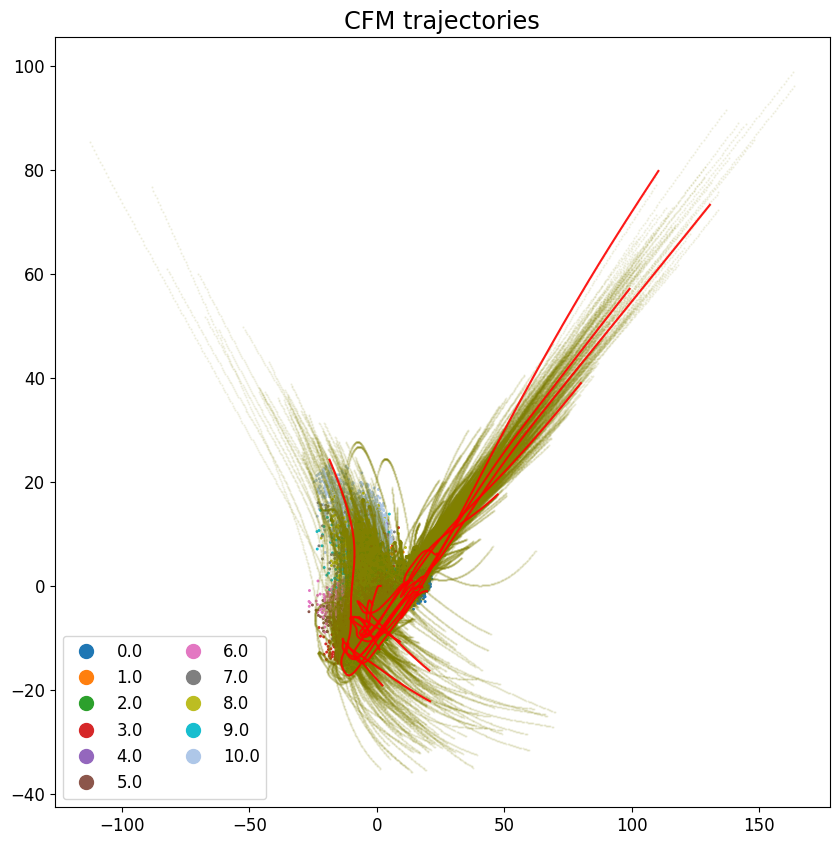

In [23]:
plot_node_path(ot_cfm_model, X)

In [25]:
sigma = 0.2
dim = adata.obsm["X_pca"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="basic_entropic_ot")
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [05:00<00:00, 33.25it/s]


## Basic entropic prior (converges to sinkhorn)


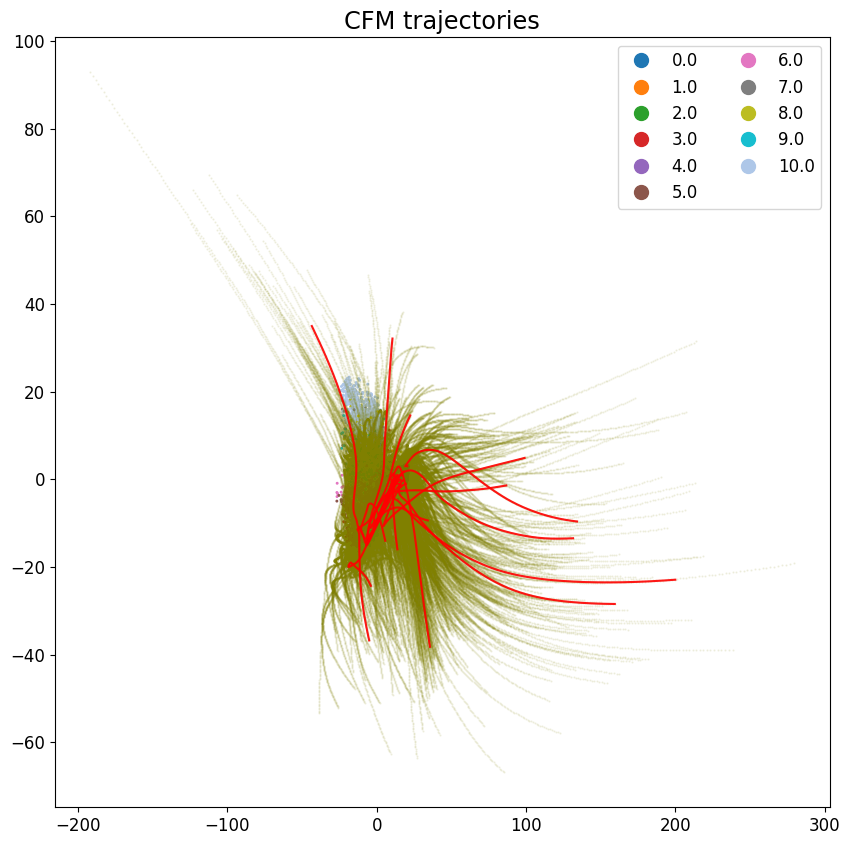

In [26]:
plot_node_path(ot_cfm_model, X)

In [27]:
sigma = 0.2
dim = adata.obsm["X_pca"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="sinkhorn")
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

  0%|                                                                                                                               | 0/10000 [00:00<?, ?it/s]/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/home/mcb/users/msandl4/conditional-flow-matching/torchcfm/optimal_transport.py:102: UserWarning: Numerical errors in OT plan, reverting to uniform plan.
  warnings.warn("Numerical errors in OT plan, reverting to uniform plan.")
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:27<00:00, 48.18it/s]


## Sinkhorn

As for the phate embeddings there are numerical errors so it follows a uniform transport plan

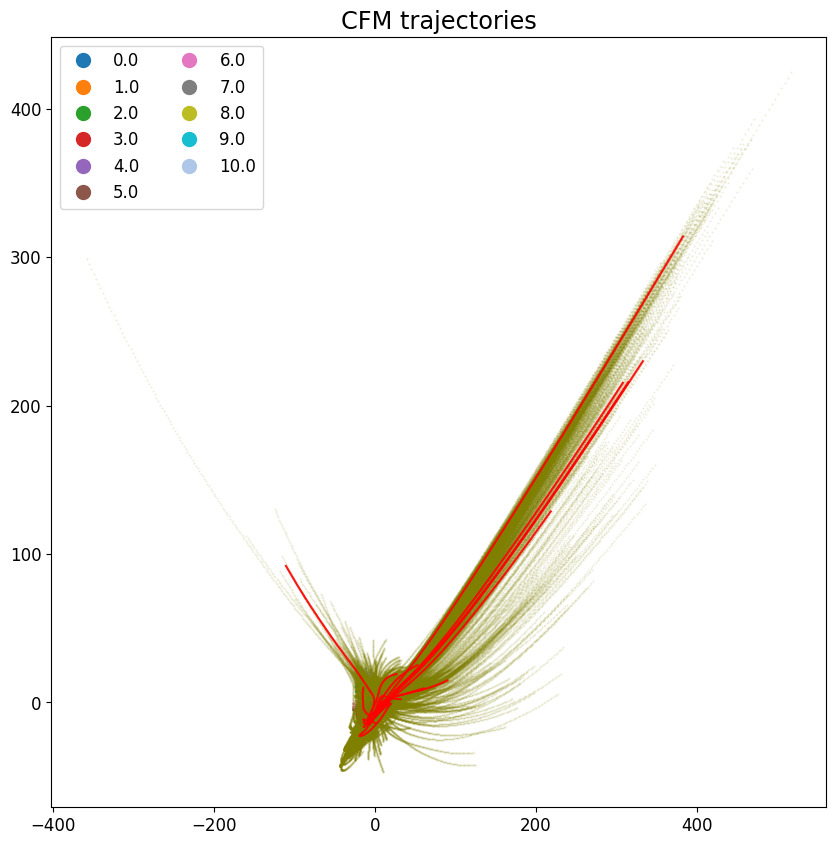

In [28]:
plot_node_path(ot_cfm_model, X)

General notes:
 - stil some alright looking trajectories
 - A lot less clear but some correct looking trajectories are present nonetheless

In [ ]:
s